In [2]:
# Preparazione ambiente 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from scipy.stats import ttest_ind
import yfinance as yf
import pickle
from scipy.stats import chi2
import utility as ut

In [14]:
ticker_list = ["^GSPC", "^DJI", "^IXIC"]
date_event = "2-04-25"
alpha_list = [0.05, 0.01]

# pd.read_csv("timeseries_sp500.csv", index_col= 0, parse_dates= True)

time_series = ut.get_historical_data(ticker_list)

time_series.to_csv("time_series.csv")

log_returns = ut.calculate_log_returns(time_series)

df_normal, df_distress = ut.data_slicer(log_returns, event_date= date_event)

var_storico_N = ut.calculate_historical_var(df_normal)
var_storico_D = ut.calculate_historical_var(df_distress)

display(abs(var_storico_N), abs(var_storico_D))

[*********************100%***********************]  3 of 3 completed


Alpha,0.01,0.05
Ticker,,
^DJI,0.017707,0.011464
^GSPC,0.021145,0.014423
^IXIC,0.029914,0.019065


Alpha,0.01,0.05
Ticker,,
^DJI,0.025242,0.016687
^GSPC,0.032204,0.016721
^IXIC,0.042780,0.023219


In [4]:
ES_N = ut.calculate_expected_shortfall(df_normal, var_storico_N)
ES_D = ut.calculate_expected_shortfall(df_distress, var_storico_D)

display(abs(ES_N), abs(ES_D))

,0.01,0.05
^DJI,0.022350,0.015760
^GSPC,0.025953,0.018420
^IXIC,0.034733,0.024964


,0.01,0.05
^DJI,0.040830,0.024552
^GSPC,0.048812,0.028458
^IXIC,0.055167,0.036041


In [5]:
tail_risk_N = ES_N/var_storico_N
tail_risk_D = ES_D/var_storico_D

display(tail_risk_N, tail_risk_D)

,0.01,0.05
^DJI,1.262164,1.374807
^GSPC,1.227373,1.277170
^IXIC,1.161110,1.309377


,0.01,0.05
^DJI,1.617504,1.471320
^GSPC,1.515703,1.701924
^IXIC,1.289544,1.552206


In [6]:
variazione_VaR = ut.get_variations(var_storico_N, var_storico_D)
variazione_ES = ut.get_variations(ES_N, ES_D)

display(variazione_VaR, variazione_ES)

Alpha,0.01,0.05
Ticker,,
^DJI,0.425531,0.455642
^GSPC,0.522981,0.159383
^IXIC,0.430110,0.217884


,0.01,0.05
^DJI,0.826864,0.557829
^GSPC,0.880754,0.544965
^IXIC,0.588299,0.443745


**Mentre per NASDAQ e S&P 500 il modello rimane statisticamente accurato (p-value > 0.01), per il Dow Jones osserviamo un p-value di 0.001**

**Questo indica che le tariffe hanno colpito i titoli industriali (clue chips) in modo così violento da rendere i dati storici degli ultimi 600 giorni non più rappresentativi della nuova realtà di rischio**

In [ ]:
t_kupiec = ut.test_kupiec(df_distress, var_storico_N)

display(t_kupiec)

Ticker,^DJI,^GSPC,^IXIC
Violazioni,9.000000,7.00000,6.000000
p-value,0.001028,0.01535,0.049737


<Figure size 1200x600 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

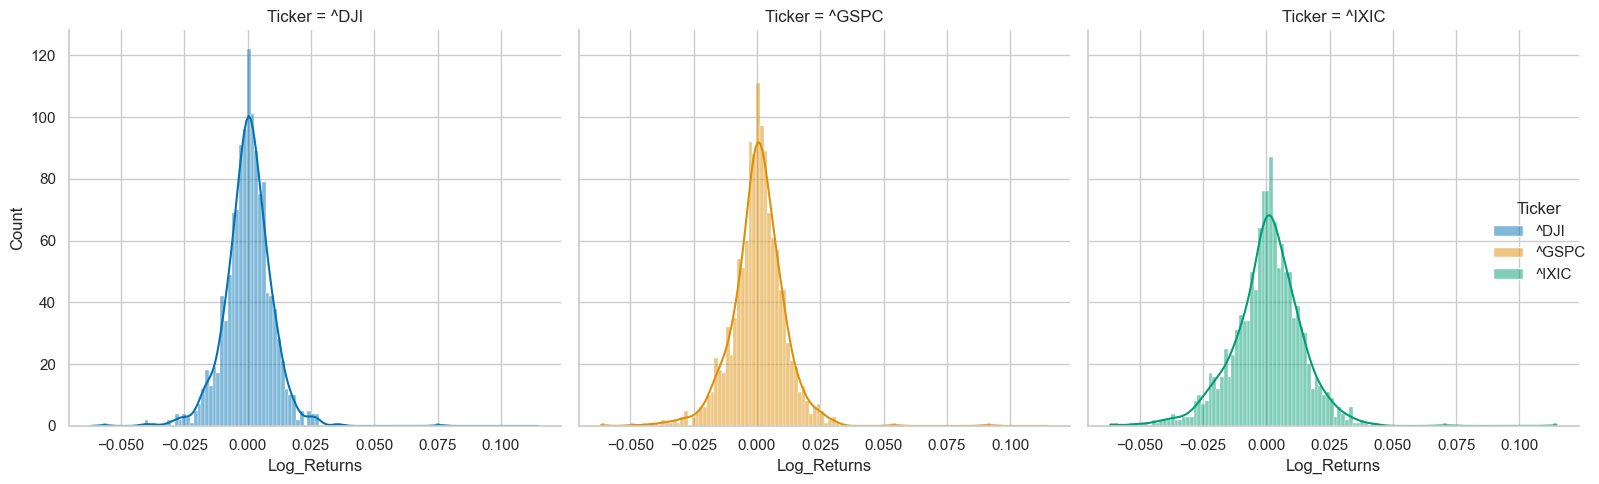

In [16]:
# Data Visualization
sns.set_theme(style="whitegrid", context="notebook", palette= "colorblind", )
canva = plt.figure(figsize= (12, 6))

col = log_returns.columns.to_list()
color_list = sns.color_palette("colorblind")

plt.figure(figsize= (10, 5))

df_log_r_tidy = log_returns.reset_index().melt(id_vars="Date", var_name="Ticker", value_name="Log_Returns")

sns.displot(
    data = df_log_r_tidy,
    kind= "hist",
    x = "Log_Returns", 
    kde = True, 
    hue = "Ticker",
    col = "Ticker"
    )

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

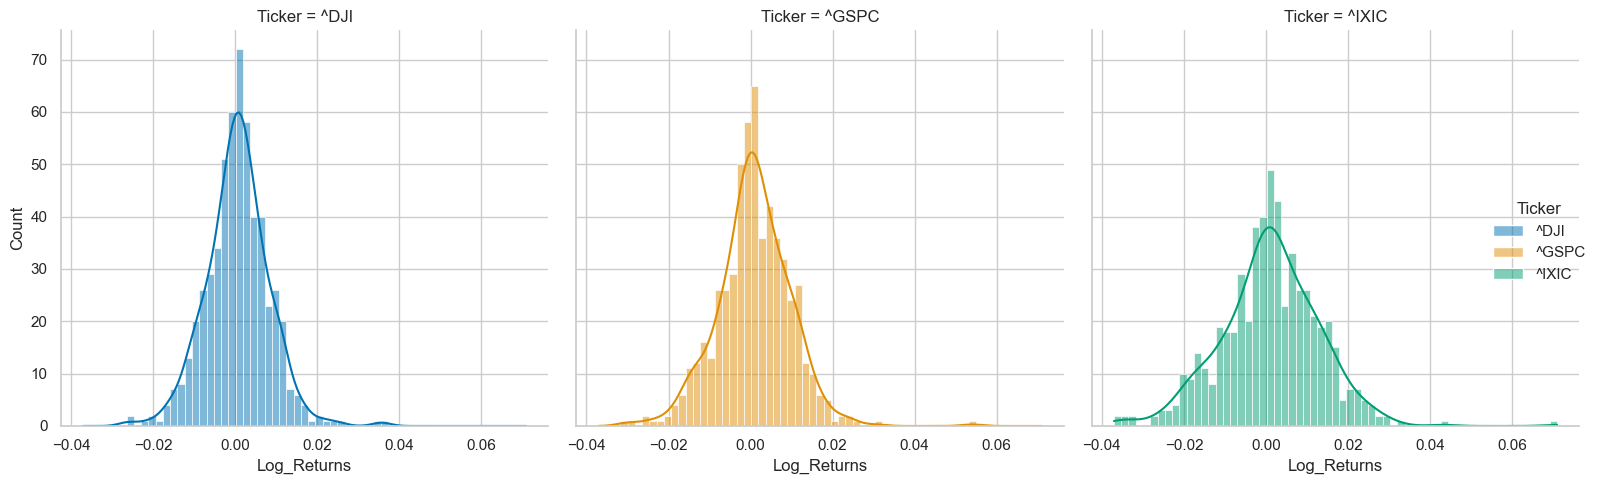

In [ ]:
plt.figure(figsize= (12, 6))

df_normal_tidy = df_normal.reset_index().melt(id_vars="Date", var_name="Ticker", value_name="Log_Returns")

sns.displot(
    data = df_normal_tidy, kind= "hist",
    x = "Log_Returns",
    kde = True,
    hue = "Ticker",
    col = "Ticker",
    )

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

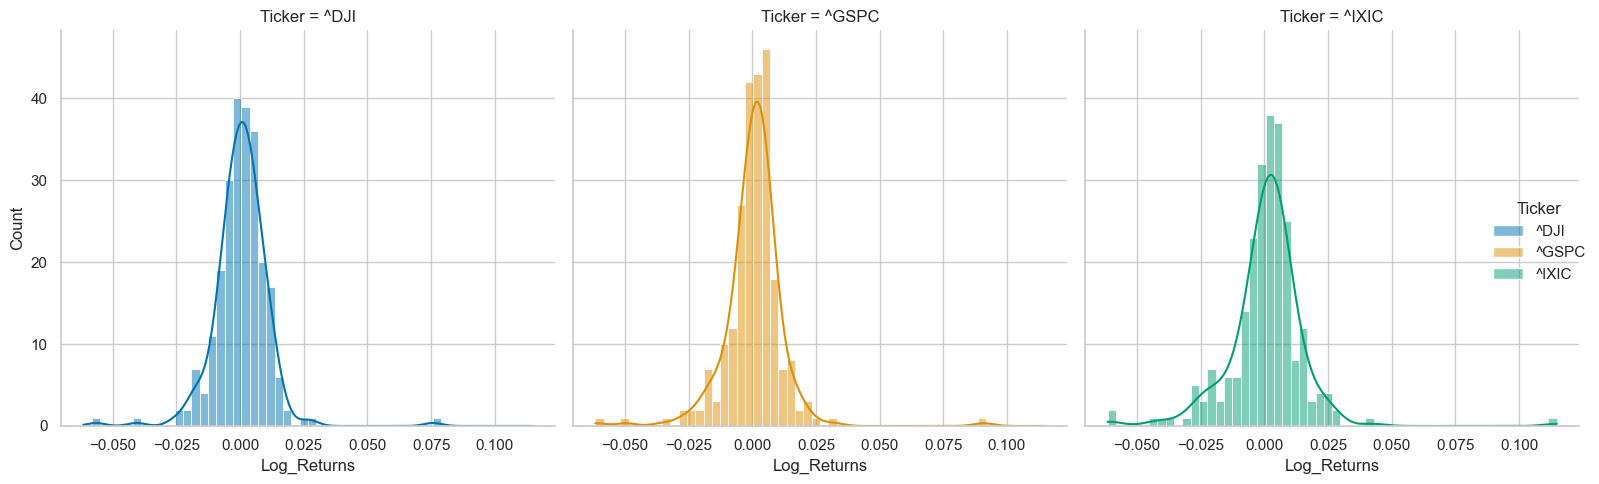

In [ ]:
plt.figure(figsize= (12, 6))

df_normal_tidy = df_distress.reset_index().melt(id_vars="Date", var_name="Ticker", value_name="Log_Returns")

sns.displot(
    data = df_normal_tidy, kind= "hist",
    x = "Log_Returns",
    kde = True, 
    hue = "Ticker",
    col = "Ticker",
    
    )

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

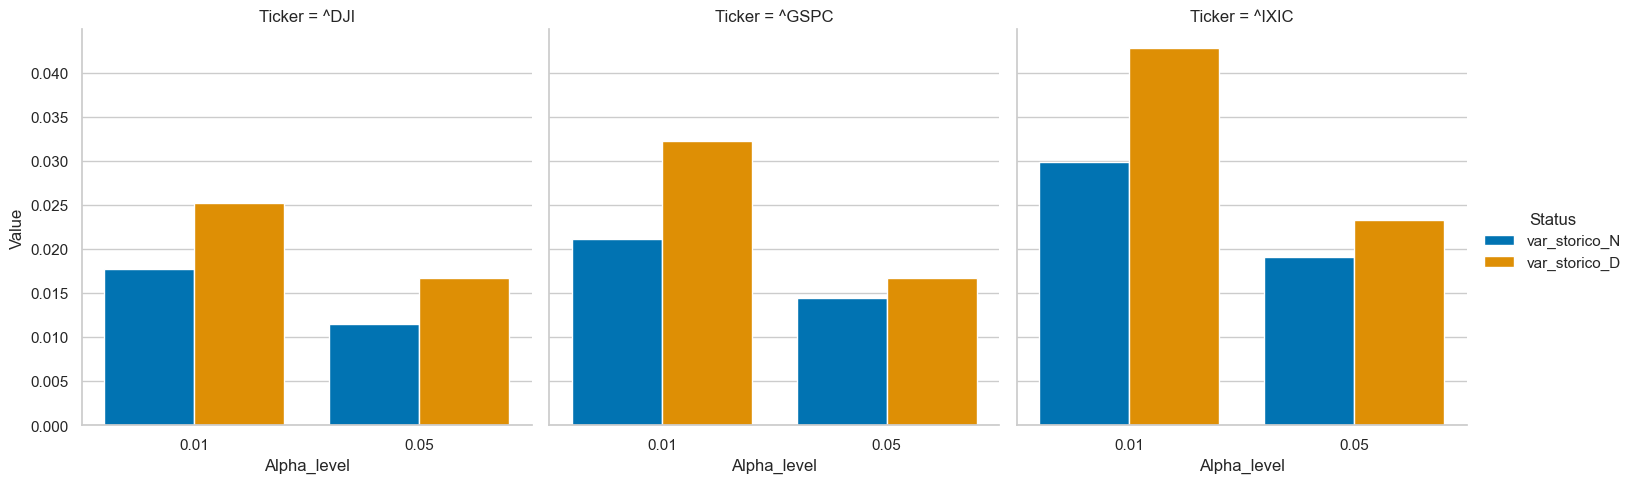

In [ ]:
df_var_concat = pd.concat(
    [abs(var_storico_N), abs(var_storico_D)],
    keys= ["var_storico_N", "var_storico_D"],
    names = ["Status", "Ticker"]
    )

df_var_concat = df_var_concat.reset_index().melt(id_vars = ["Status", "Ticker"], var_name = "Alpha_level", value_name= "Value")

plt.figure(figsize= (12, 6))

sns.catplot(
    data= df_var_concat, kind = "bar",
    x = "Alpha_level", y = "Value",
    legend= True,
    hue = "Status",
    col = "Ticker",
    saturation = 1,
    palette= "colorblind"
    )


plt.show()